In [1]:
import pandas as pd
import numpy as np
import sklearn
import tensorflow
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

tensorflow: 2.19.0
pandas    : 2.2.2
numpy     : 1.26.4
matplotlib: 3.9.2
sklearn   : 1.5.1
keras     : 3.10.0



In [3]:
def automatiza_forecast(df_para_treinar_modelo):

    scaler = StandardScaler()
    
    scaler = scaler.fit(df_para_treinar_modelo)
    
    df_para_treinar_modelo_scaled = scaler.transform(df_para_treinar_modelo)

    x_treino = []
    
    y_treino = []

    n_futuro = 1   
    
    n_past = 15 

    for i in range(n_past, len(df_para_treinar_modelo_scaled) - n_futuro + 1):
        x_treino.append(df_para_treinar_modelo_scaled[i - n_past:i, :])
        y_treino.append(df_para_treinar_modelo_scaled[i + n_futuro - 1:i + n_futuro, 0])

    x_treino, y_treino = np.array(x_treino), np.array(y_treino)

    modelo_ = Sequential()
    
    modelo_.add(LSTM(128, 
                        activation = "sigmoid", 
                        input_shape = (x_treino.shape[1], x_treino.shape[2]), 
                        return_sequences = False))
    
    modelo_.add(Dense(y_treino.shape[1]))

    modelo_.compile(optimizer = 'adam', loss = 'mean_squared_error')

    history = modelo_.fit(x_treino, y_treino, epochs = 10, batch_size = 16, validation_split = 0.1, verbose = 0)

    n_past = 15
    
    last_sequence = df_para_treinar_modelo_scaled[-n_past:]
    
    last_sequence = np.reshape(last_sequence, (1, n_past, len(cols)))

    previsao = modelo_.predict(last_sequence)

    previsao_indicadores = np.repeat(previsao, df_para_treinar_modelo.shape[1], axis = -1)
    
    y_pred_futuro = scaler.inverse_transform(previsao_indicadores)[:,0]
    
    return y_pred_futuro[0] 

In [4]:
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/contabilidade.csv')
df = df.sort_values('meses')
df = df.reset_index(drop=True)
cols = list(df)[1:8]
previsoes_1_ano = {} 

In [5]:
for column in cols:
    
    target_column = column

    df_treino = df[[target_column] + [col for col in cols if col != target_column]].astype(float)

    pred = automatiza_forecast(df_treino)
    
    previsoes_1_ano[target_column] = round(pred, 2)

C:\Users\conta\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


C:\Users\conta\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


C:\Users\conta\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


C:\Users\conta\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


C:\Users\conta\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [6]:
df_previsoes_1_ano = pd.DataFrame([previsoes_1_ano])
df_previsoes_1_ano["meses"] = '2023-09'
df_combined = pd.concat([df, df_previsoes_1_ano], ignore_index = True)
df_combined = df_combined.reset_index(drop = True)

In [7]:
#Salvar previsão em disco
df_combined.to_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/part4/df_previsoes_1_ano.ipynb')

In [8]:
#Carregar dataset com previsões
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/part4/df_previsoes_1_ano.ipynb')

In [9]:
def plot_forecast(df):  

    df = df.iloc[:, 1:]  
    
    num_cols = 3  
    
    num_rows = (len(df.columns) - 1) // num_cols + 1  

    figsize = (num_cols * 6, num_rows * 4)  
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize = figsize)  

    axes = axes.flatten()  

    for i, col in enumerate(df.columns): 
        
        ax = axes[i]  

        x_values = df.index  
        y_values = df[col]  

        ax.plot(x_values, y_values)  
        ax.set_title(col)  
        ax.set_xlabel('Trimestres')  
        ax.set_ylabel('Valor')  
        ax.grid(True)  
        ax.tick_params(axis = 'x', rotation = 45)  
        ax.set_xticklabels([])  

    if len(df.columns) < len(axes):  
        
        for j in range(len(df.columns), len(axes)):  
            
            fig.delaxes(axes[j])  

    fig.tight_layout()  

    plt.show() 

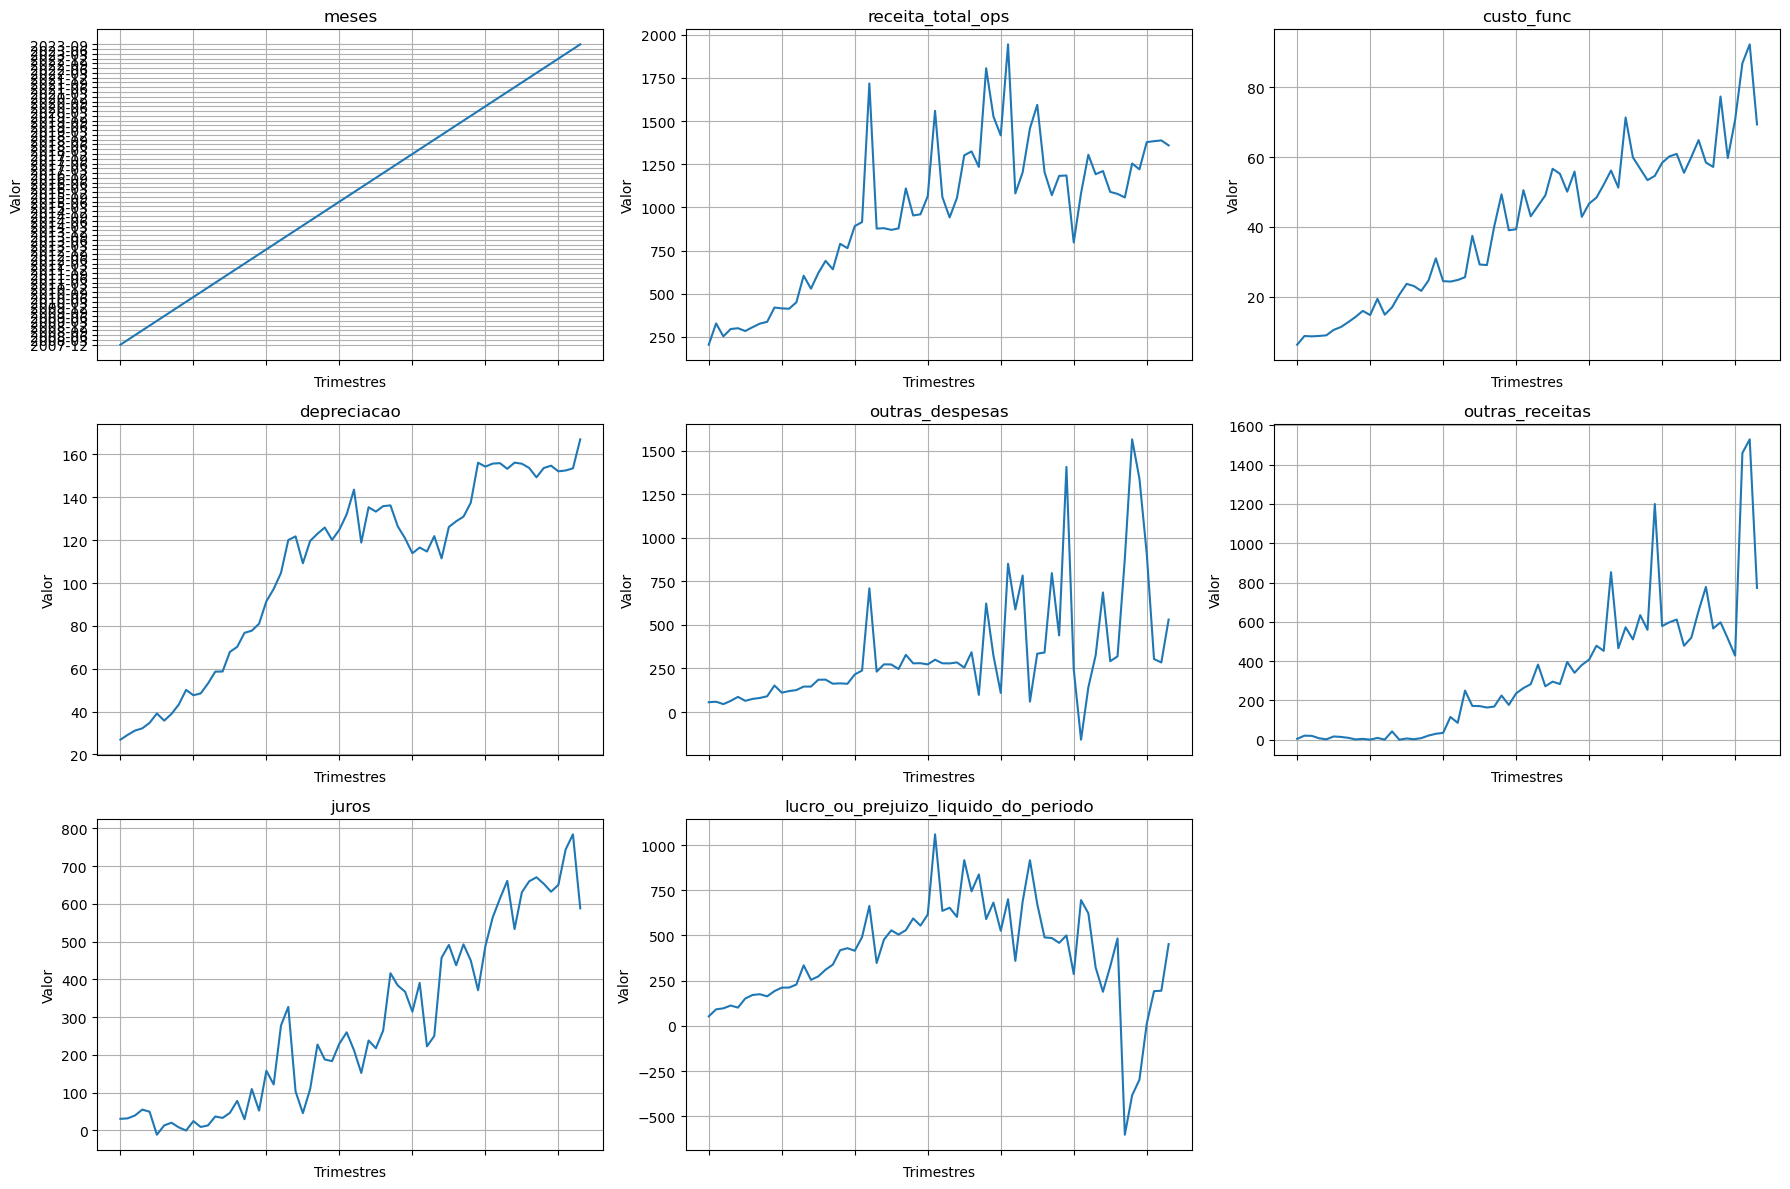

In [11]:
plot_forecast(df)